# Aula Prática: Identificação e Tratamento de Outliers

Bem-vindos! Como vimos nas discussões teóricas sobre média e variância, a presença de valores atípicos (*outliers*) pode distorcer drasticamente as medidas de tendência central, inflar a dispersão e destruir a precisão dos nossos modelos inferenciais e preditivos.

**Atenção:** Um outlier nem sempre é um erro. Às vezes, ele é o sinal mais importante do seu conjunto de dados (ex: detecção de fraudes, falhas em equipamentos). O tratamento que aplicamos depende da *natureza* do dado.
ontos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurações visuais
sns.set_theme(style="whitegrid")

## 1. Geração de Dados Sintéticos (Simulando o Mundo Real)

Vamos simular a **Renda Mensal** de 1.000 clientes.
* **Grupo Base (95%):** Segue uma distribuição normal (média de R$ 5.000, desvio padrão de R$ 1.500).
* **Grupo Atípico (5%):** Valores extremos simulados uniformemente entre R$ 20.000 e R$ 100.000 (podem ser CEOs, herdeiros ou falhas de sistema).

In [2]:
# 950 clientes com renda "comum"
np.random.seed(42)
renda_normal = np.random.normal(loc=5000, scale=1500, size=950)

# 50 clientes com renda ALTA
np.random.seed(42)
renda_outliers = np.random.uniform(low=20000, high=100000, size=50)

# Combinando em um DataFrame
dados = np.concatenate([renda_normal, renda_outliers])
df = pd.DataFrame({'Renda': dados})

# Embaralhando as linhas
df = df.sample(frac=1).reset_index(drop=True)

# Observando o impacto imediato na Média vs Mediana
print("Estatísticas Descritivas:")
display(df.describe().round(2))

print(f"\nAtenção: A média ({df['Renda'].mean():.2f}) está fortemente puxada para cima em relação à mediana ({df['Renda'].median():.2f}).")

Estatísticas Descritivas:


,Renda
count,1000.00
mean,7562.32
std,12255.52
min,138.10
25%,4099.52
50%,5119.43
75%,6152.44
max,97592.79



Atenção: A média (7562.32) está fortemente puxada para cima em relação à mediana (5119.43).


## 2. Identificação e Diagnóstico de Outliers

Podemos identificar outliers de forma visual (Boxplots e Histogramas) e analítica (Z-Score e IQR).

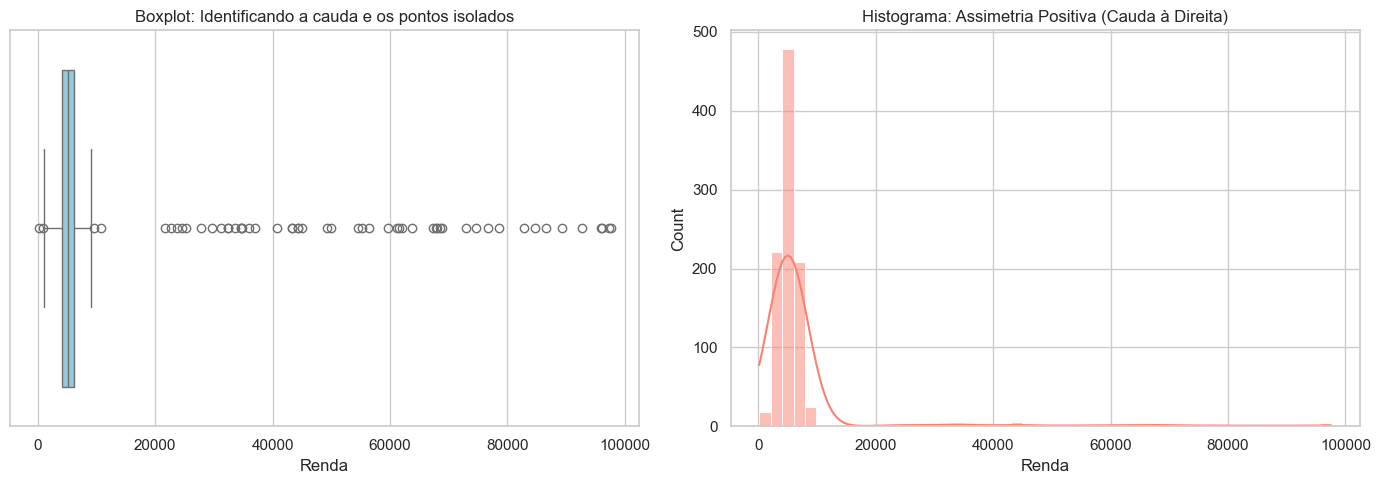

In [3]:
# Diagnóstico Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df, x='Renda', ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot: Identificando a cauda e os pontos isolados')

# Histograma
sns.histplot(data=df, x='Renda', bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Histograma: Assimetria Positiva (Cauda à Direita)')

plt.tight_layout()
plt.show()

In [4]:
# Método 1: Z-Score (Mede a distância da média em desvios padrões)
# Cuidado: O Z-score usa a média e o desvio padrão, que também são afetados por outliers!
z_scores = np.abs(stats.zscore(df['Renda']))
outliers_z = df[z_scores > 3] # Limite tradicional de 3 desvios
print(f"Outliers identificados pelo Z-Score (Z > 3): {len(outliers_z)}")

# Método 2: IQR - Interquartile Range (Mais Robusto)
# Usa quartis (baseados na mediana), logo não sofre tanta distorção.
Q1 = df['Renda'].quantile(0.25)
Q3 = df['Renda'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = df[(df['Renda'] < limite_inferior) | (df['Renda'] > limite_superior)]
print(f"Outliers identificados pelo limite IQR: {len(outliers_iqr)}\n")
print(f"Limite Superior do IQR (Teto normal): R$ {limite_superior:.2f}")

Outliers identificados pelo Z-Score (Z > 3): 31
Outliers identificados pelo limite IQR: 54

Limite Superior do IQR (Teto normal): R$ 9231.82


## 3. Tratamento de Outliers

Como modeladores, temos algumas ferramentas no cinto de utilidades para tratar esses casos, dependendo do nosso objetivo.

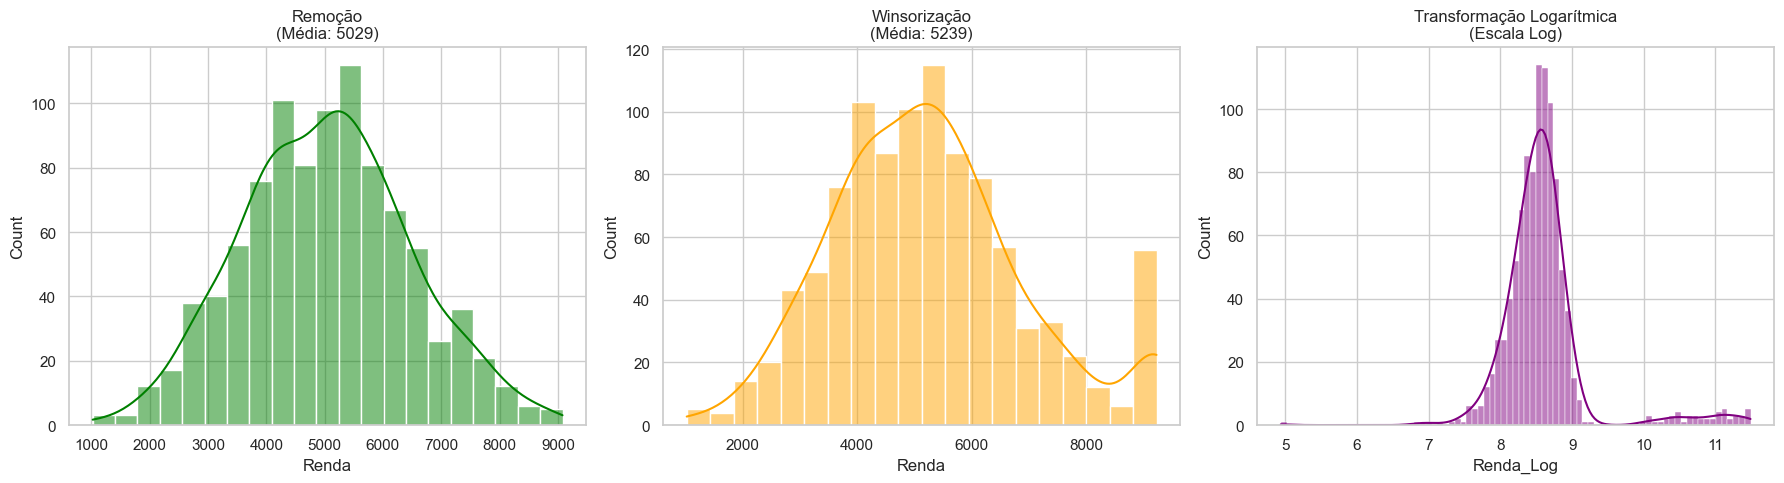

In [5]:
# Abordagem A: Remoção (Trimming)
# Quando usar: Se você tem certeza de que o outlier é um erro (ex: idade = 200 anos).
df_trim = df[(df['Renda'] >= limite_inferior) & (df['Renda'] <= limite_superior)].copy()

# Abordagem B: Winsorização (Capping)
# Quando usar: Os valores são reais, mas você não quer que eles dominem o modelo (ex: modelos lineares).
# Nós os "cortamos" e substituímos pelo limite aceitável.
df_winsor = df.copy()
df_winsor['Renda'] = np.clip(df_winsor['Renda'], a_min=limite_inferior, a_max=limite_superior)

# Abordagem C: Transformação Logarítmica
# Quando usar: A relação não é linear ou você deseja "suavizar" a magnitude dos grandes números, 
# aproximando os dados de uma distribuição Normal.
df_log = df.copy()
df_log['Renda_Log'] = np.log1p(df_log['Renda'])

# Visualizando o impacto das 3 abordagens
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_trim['Renda'], kde=True, ax=axes[0], color='green')
axes[0].set_title(f'Remoção\n(Média: {df_trim["Renda"].mean():.0f})')

sns.histplot(df_winsor['Renda'], kde=True, ax=axes[1], color='orange')
axes[1].set_title(f'Winsorização\n(Média: {df_winsor["Renda"].mean():.0f})')

sns.histplot(df_log['Renda_Log'], kde=True, ax=axes[2], color='purple')
axes[2].set_title(f'Transformação Logarítmica\n(Escala Log)')

plt.tight_layout()
plt.show()